In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, fftshift, fftfreq
from scipy.signal import windows

# Set style for better plots
plt.style.use('seaborn-v0_8-whitegrid')

# Common parameters
fs = 1000  # Sampling frequency (Hz)
T = 1.0    # Total duration (seconds)
N = int(fs * T)  # Number of samples
t = np.linspace(0, T, N, endpoint=False)  # Time vector



1(a) Generating sinusoidal signal (5 Hz)...
1(b) Plotting time-domain waveform...
1(c) Computing DTFT (continuous frequency spectrum)...
1(d) Computing DFT (discrete frequency spectrum)...


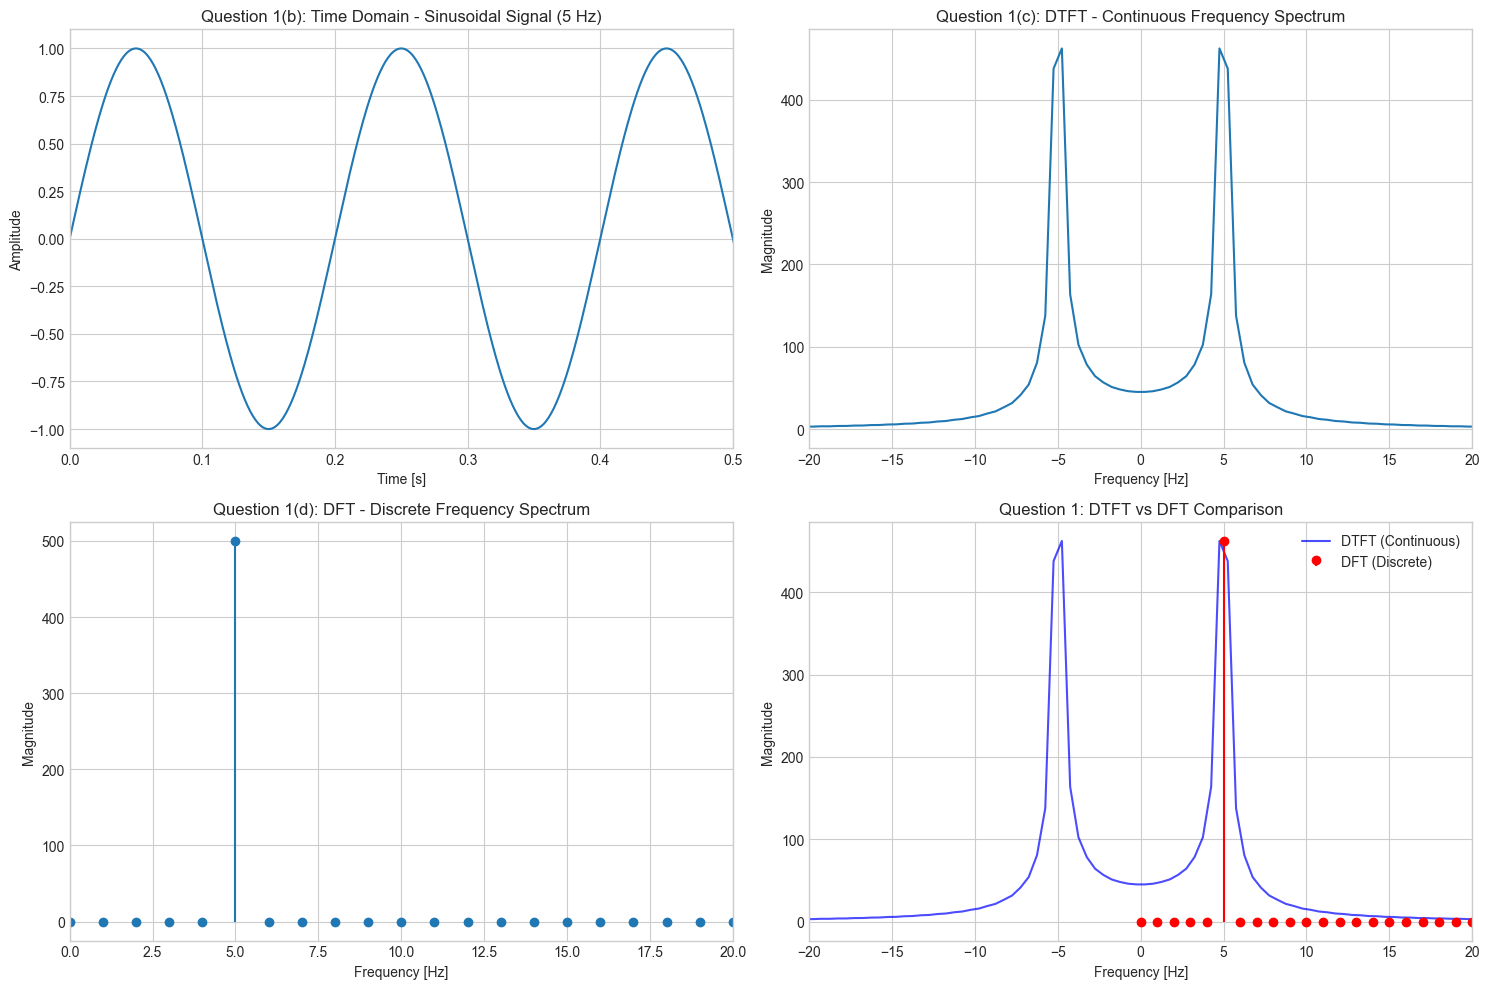

In [ ]:
# QUESTION 1: Basic Sinusoidal Signal

# Part 1(a): Generate basic sinusoidal signal
print("\n1(a) Generating sinusoidal signal (5 Hz)...")
f1 = 5  # Frequency (Hz)
signal1 = np.sin(2 * np.pi * f1 * t)

# Part 1(b): Plot time-domain waveform
print("1(b) Plotting time-domain waveform...")
plt.figure(figsize=(15, 10))

plt.subplot(2, 2, 1)
plt.plot(t, signal1)
plt.title('Question 1(b): Time Domain - Sinusoidal Signal (5 Hz)')
plt.xlabel('Time [s]')
plt.ylabel('Amplitude')
plt.grid(True)
plt.xlim(0, 0.5)  # Show first 0.5 seconds for clarity

# Part 1(c): Compute and plot DTFT (continuous frequency spectrum)
print("1(c) Computing DTFT (continuous frequency spectrum)...")
# For DTFT, we use a fine frequency resolution
freqs_dtft = np.linspace(-fs/2, fs/2, 2000)
dtft1 = np.zeros(len(freqs_dtft), dtype=complex)

for i, freq in enumerate(freqs_dtft):
    dtft1[i] = np.sum(signal1 * np.exp(-2j * np.pi * freq * t))

plt.subplot(2, 2, 2)
plt.plot(freqs_dtft, np.abs(dtft1))
plt.title('Question 1(c): DTFT - Continuous Frequency Spectrum')
plt.xlabel('Frequency [Hz]')
plt.ylabel('Magnitude')
plt.grid(True)
plt.xlim(-20, 20)

# Part 1(d): Compute and plot DFT (discrete frequency spectrum)
print("1(d) Computing DFT (discrete frequency spectrum)...")
dft1 = fft(signal1)
freqs_dft = fftfreq(N, 1/fs)

plt.subplot(2, 2, 3)
plt.stem(freqs_dft[:N//2], np.abs(dft1[:N//2]), basefmt=" ")
plt.title('Question 1(d): DFT - Discrete Frequency Spectrum')
plt.xlabel('Frequency [Hz]')
plt.ylabel('Magnitude')
plt.grid(True)
plt.xlim(0, 20)

# Combined plot for comparison
plt.subplot(2, 2, 4)
plt.plot(freqs_dtft, np.abs(dtft1), 'b-', label='DTFT (Continuous)', alpha=0.7)
plt.stem(freqs_dft[:N//2], np.abs(dft1[:N//2])/max(np.abs(dft1[:N//2]))*max(np.abs(dtft1)), 
         'r', basefmt=" ", label='DFT (Discrete)')
plt.title('Question 1: DTFT vs DFT Comparison')
plt.xlabel('Frequency [Hz]')
plt.ylabel('Magnitude')
plt.legend()
plt.grid(True)
plt.xlim(-20, 20)

plt.tight_layout()
plt.show()


2(a) Generating composite signal...
2(b) Plotting time-domain waveform...
2(c) Computing DTFT...


(-80.0, 80.0)

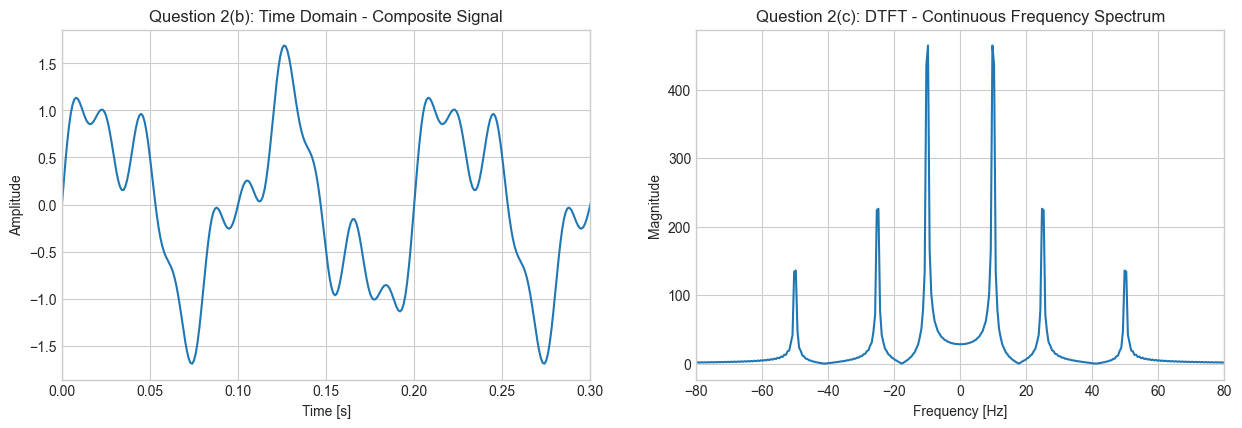

In [9]:
# QUESTION 2: Composite Signal

# Part 2(a): Generate composite signal
print("\n2(a) Generating composite signal...")
f2_1, A1 = 10, 1.0   # First component: 10 Hz, amplitude 1
f2_2, A2 = 25, 0.5   # Second component: 25 Hz, amplitude 0.5
f2_3, A3 = 50, 0.3   # Third component: 50 Hz, amplitude 0.3

signal2 = (A1 * np.sin(2 * np.pi * f2_1 * t) + 
           A2 * np.sin(2 * np.pi * f2_2 * t) + 
           A3 * np.sin(2 * np.pi * f2_3 * t))

# Part 2(b): Plot time-domain waveform
print("2(b) Plotting time-domain waveform...")
plt.figure(figsize=(15, 10))

plt.subplot(2, 2, 1)
plt.plot(t, signal2)
plt.title('Question 2(b): Time Domain - Composite Signal')
plt.xlabel('Time [s]')
plt.ylabel('Amplitude')
plt.grid(True)
plt.xlim(0, 0.3)

# Part 2(c): Compute and plot DTFT
print("2(c) Computing DTFT...")
dtft2 = np.zeros(len(freqs_dtft), dtype=complex)
for i, freq in enumerate(freqs_dtft):
    dtft2[i] = np.sum(signal2 * np.exp(-2j * np.pi * freq * t))

plt.subplot(2, 2, 2)
plt.plot(freqs_dtft, np.abs(dtft2))
plt.title('Question 2(c): DTFT - Continuous Frequency Spectrum')
plt.xlabel('Frequency [Hz]')
plt.ylabel('Magnitude')
plt.grid(True)
plt.xlim(-80, 80)